In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"lihseyn","key":"ab5b99252f4ad3b64b350fb0abad3ed9"}'}

In [2]:
!mk dir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

/bin/bash: line 1: mk: command not found
cp: cannot create regular file '/root/.kaggle/': Not a directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [3]:
!kaggle datasets download -d sbaghbidi/human-faces-object-detection

Dataset URL: https://www.kaggle.com/datasets/sbaghbidi/human-faces-object-detection
License(s): unknown
100% 498M/498M [00:04<00:00, 128MB/s] 



In [4]:
!unzip human-faces-object-detection.zip

Archive:  human-faces-object-detection.zip
  inflating: faces.csv               
  inflating: images/00000003.jpg     
  inflating: images/00000004.jpg     
  inflating: images/00000005.jpg     
  inflating: images/00000006.jpg     
  inflating: images/00000008.jpg     
  inflating: images/00000011.jpg     
  inflating: images/00000012.jpg     
  inflating: images/00000015.jpg     
  inflating: images/00000018.jpg     
  inflating: images/00000020.jpg     
  inflating: images/00000022.jpg     
  inflating: images/00000023.jpg     
  inflating: images/00000024.jpg     
  inflating: images/00000026.jpg     
  inflating: images/00000031.jpg     
  inflating: images/00000032.jpg     
  inflating: images/00000041.jpg     
  inflating: images/00000044.jpg     
  inflating: images/00000045.jpg     
  inflating: images/00000047.jpg     
  inflating: images/00000050.jpg     
  inflating: images/00000051.jpg     
  inflating: images/00000055.jpg     
  inflating: images/00000058.jpg     
  infla

In [5]:
import pandas as pd
import os

In [6]:
csv_fayli = 'faces.csv'
label_fayli = 'labels'

os.makedirs(label_fayli, exist_ok=True)

df=pd.read_csv(csv_fayli)

for index,row in df.iterrows():
  sekil_adi = row['image_name']
  img_w = row['width']
  img_h = row['height']
  x0 = row['x0']
  y0 = row['y0']
  x1 = row['x1']
  y1 = row['y1']

  box_width = x1-x0
  box_height = y1-y0
  x_center = x0 +(box_width/2)
  y_center = y0 +(box_height/2)

  norm_x_center = x_center/img_w
  norm_y_center = y_center/img_h
  norm_box_width = box_width/img_w
  norm_box_height = box_height/img_h

  class_id = 0

  text_adi = os.path.splitext(sekil_adi)[0] + ".txt"
  text_fayli = os.path.join(label_fayli, text_adi)

  with open(text_fayli,'a') as f:
    f.write(f"{class_id} {norm_x_center:.6f} {norm_y_center:.6f} {norm_box_width:.6f} {norm_box_height:.6f}\n")

print("butun fayllar yaradildi")

butun fayllar yaradildi


In [7]:
pip install split-folders

In [9]:
import splitfolders

splitfolders.ratio(
    "ana_qovluq",
    output = 'yolo_dataset',
    seed = 42,
    ratio = (0.8,0.2),
    move = False
)

Copying files: 4408 files [00:03, 1290.24 files/s]


In [10]:
config_content = """
path: /content/yolo_dataset
train: train/images
val: val/images

nc: 1
names: ['face']
"""

with open('dataa.yaml', 'w') as f:
    f.write(config_content)

print("Created data.yaml with YOLO configuration.")

Created data.yaml with YOLO configuration.


In [12]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 28.8 MB/s eta 0:00:00


In [13]:
from ultralytics import YOLO

model = YOLO('yolov8m.pt')

model.train(
    data='dataa.yaml',
    epochs=5,
    batch=-1,
    imgsz=640,
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.38 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataa.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f8decb6f530>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [30]:
model.val(data='dataa.yaml', plots=True)

Ultralytics 8.4.38 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1937.2±1224.7 MB/s, size: 247.1 KB)
val: Scanning /content/yolo_dataset/val/labels.cache... 441 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 441/441 88.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 2.3it/s 12.0s
                   all        441        712      0.817      0.871      0.883       0.54
Speed: 1.9ms preprocess, 19.0ms inference, 0.0ms loss, 1.5ms postprocess per image
Results saved to /content/runs/detect/val2


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f8deeed0bc0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

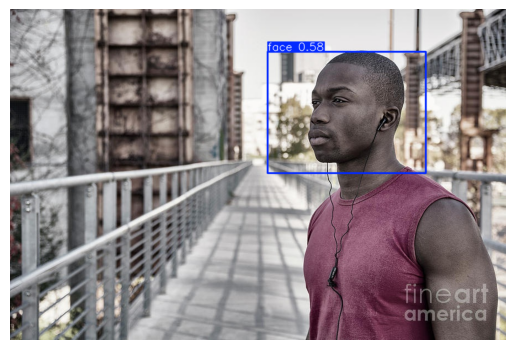

In [33]:
import random, glob, matplotlib.pyplot as plt
result = model.predict(random.choice(glob.glob('/content/yolo_dataset/val/images/*.jpg')), conf=0.5)[0]
plt.imshow(result.plot()[..., ::-1]); plt.axis('off'); plt.show()